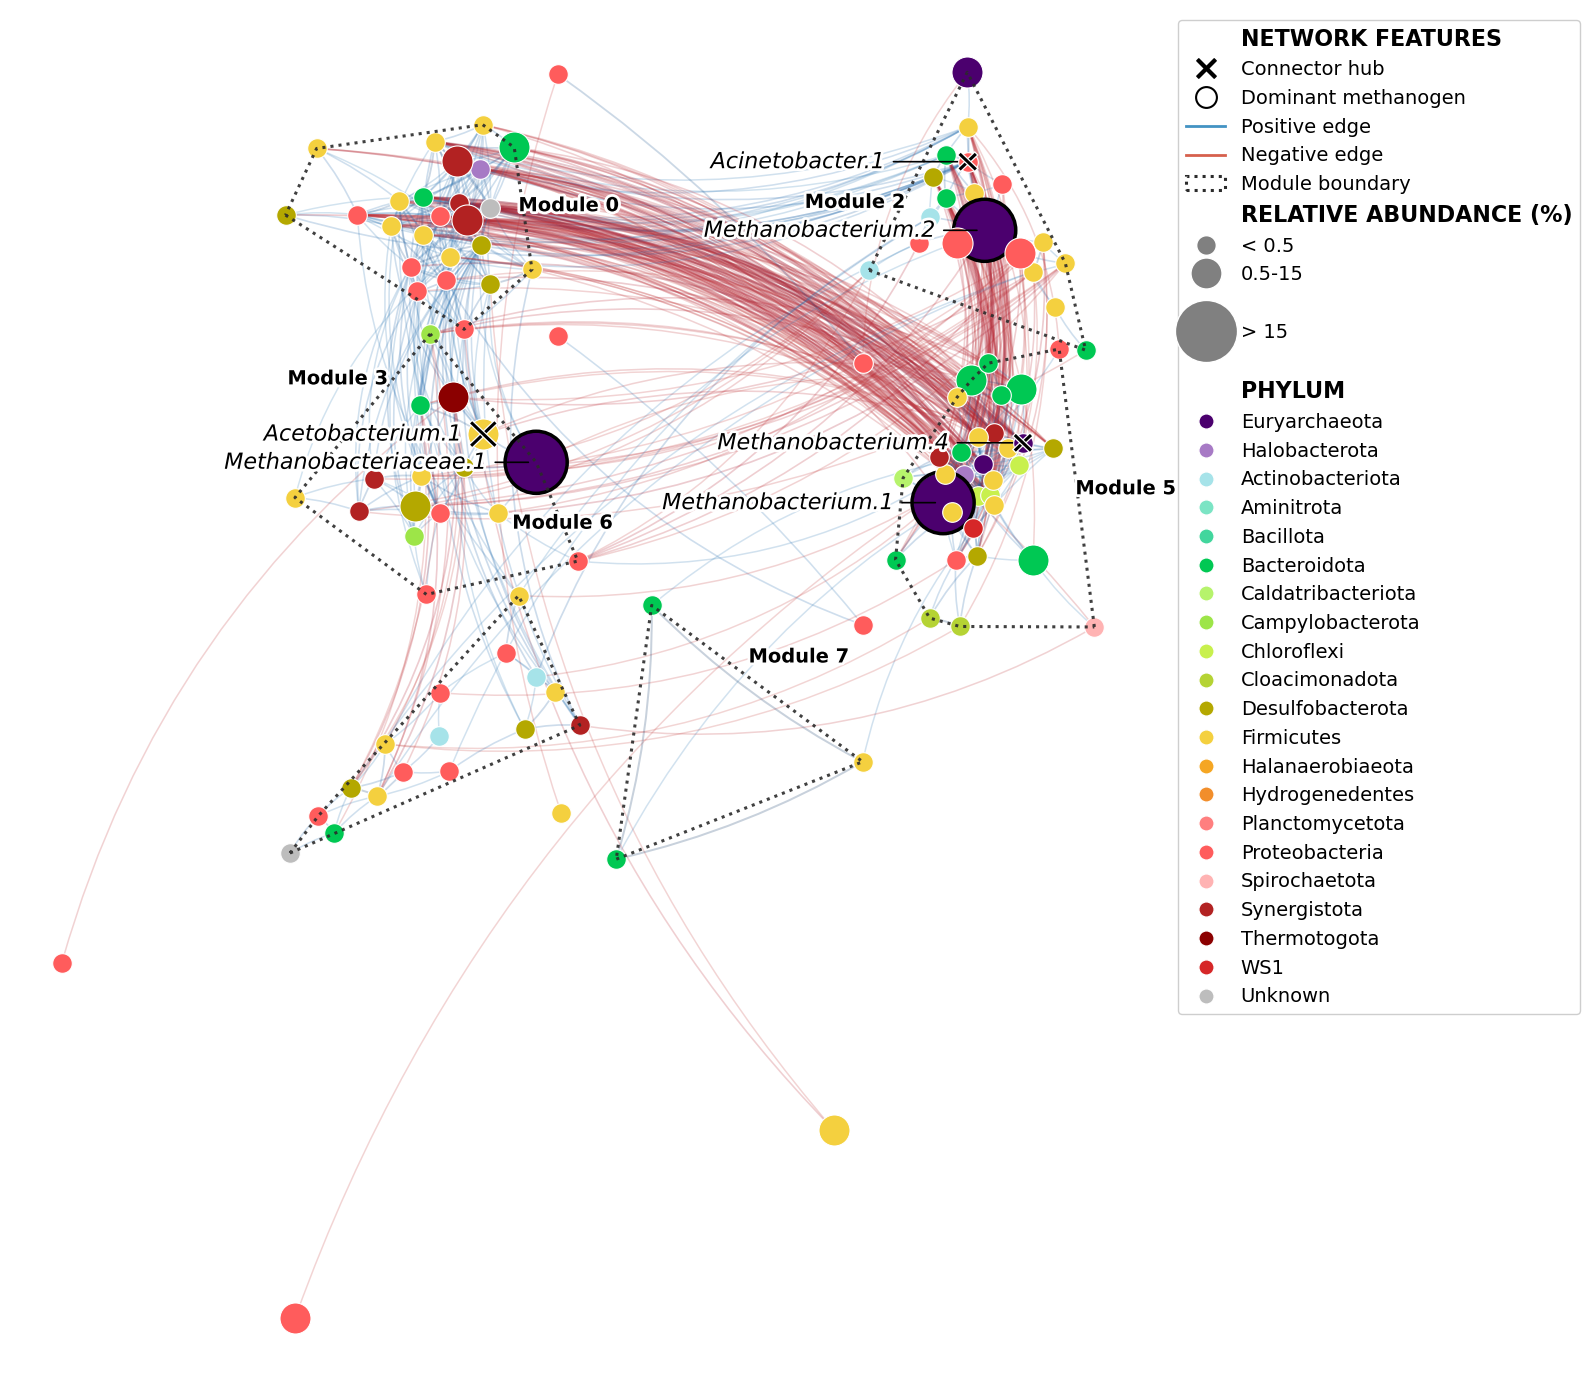

In [50]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from adjustText import adjust_text
import matplotlib.patheffects as pe
import numpy as np
from collections import defaultdict
from scipy.spatial import ConvexHull

phylum_colors = {
    'Euryarchaeota': '#4B006E',
    'Halobacterota': '#A77AC5',

    'Actinobacteriota': '#A6E3E9',
    'Aminitrota': '#7BE4C4',
    'Bacillota': '#42D69D',
    'Bacteroidota': '#00C853',
    'Caldatribacteriota': '#B6F36C',
    'Campylobacterota': '#9DE548',
    'Chloroflexi': '#C8F04D',
    'Cloacimonadota': '#B5D334',
    'Desulfobacterota': '#B4A800',
    'Firmicutes': '#F4D03F',
    'Halanaerobiaeota': '#F5A623',
    'Hydrogenedentes': '#F28E2B',
    'Planctomycetota': '#FF7F7F',
    'Proteobacteria': '#FF5C5C',
    'Spirochaetota': '#FFB3B3',
    'Synergistota': '#B22222',
    'Thermotogota': '#8B0000',
    'WS1': '#D62728',
    'Unknown': '#BDBDBD'
}

SMALL_THRESHOLD = 0.5
MEDIUM_THRESHOLD = 5
LARGE_THRESHOLD = 15

SMALL_SIZE = 200
MEDIUM_SIZE = 500
LARGE_SIZE = 2000


#####################################
# LOAD DATA
#####################################

nodes = pd.read_csv(r"C:\Users\hnielsen\Desktop\nodes.csv")
edges = pd.read_csv(r"C:\Users\hnielsen\Desktop\edges.csv")

#####################################
# BUILD GRAPH
#####################################

G = nx.Graph()

for _, row in nodes.iterrows():
    G.add_node(
        row["Node"],
        phylum=row["Phylum"],
        domain=row["Domain"],
        abundance=row["Relative_abundance"],
        role=row["Role"],
        module=row["Module"]
    )

for _, row in edges.iterrows():
    G.add_edge(row["Source"], row["Target"], rho=row["rho"])

#####################################
# GROUP BY MODULE
#####################################

module_nodes = defaultdict(list)

for n in G.nodes:
    module_nodes[G.nodes[n]["module"]].append(n)

singletons = module_nodes.pop(-1, [])
modules = list(module_nodes.keys())

#####################################
# MODULE LAYOUT
#####################################

grid = int(np.ceil(np.sqrt(len(modules))))
module_pos = {}

for i, m in enumerate(modules):
    r = i // grid
    c = i % grid
    module_pos[m] = (c * 2.5, -r * 2.50)

#####################################
# NODE LAYOUT
#####################################

pos = {}

for m, nodes_m in module_nodes.items():

    subG = G.subgraph(nodes_m)

    local_pos = nx.spring_layout(
        subG,
        k=5.0,
        scale=1.4,
        iterations=800,
        seed=42
    )

    cx, cy = module_pos[m]

    for n, (x, y) in local_pos.items():
        pos[n] = (x + cx, y + cy)

#####################################
# SINGLETONS
#####################################

if len(singletons) > 0:

    singleton_pos = nx.spring_layout(
        G.subgraph(singletons),
        k=0.5,
        scale=2.5,
        seed=42
    )

    base_y = min([v[1] for v in module_pos.values()]) - 3

    for i, (n, (x, y)) in enumerate(singleton_pos.items()):
        pos[n] = (x * 1.5, y + base_y)

#####################################
# HULLS
#####################################

module_hulls = {}

for m, nodes_m in module_nodes.items():

    pts = np.array([pos[n] for n in nodes_m])

    if len(pts) < 3:
        continue

    hull = ConvexHull(pts)
    module_hulls[m] = pts[hull.vertices]

#####################################
# NODE STYLING
#####################################

node_fill = []
node_border = []
node_borderwidth = []
node_sizes = []

for node in G.nodes():

    attrs = G.nodes[node]

    node_fill.append(phylum_colors.get(attrs["phylum"], "#BDBDBD"))

    abundance = attrs["abundance"]

    if abundance < SMALL_THRESHOLD:
        size = SMALL_SIZE
    elif abundance < LARGE_THRESHOLD:
        size = MEDIUM_SIZE
    else:
        size = LARGE_SIZE

    node_sizes.append(size)

   # if attrs["domain"] == "Archaea":
       # node_border.append("black")
      #  node_borderwidth.append(2.5)
  #  else:
    node_border.append("white")
    node_borderwidth.append(0.8)

#####################################
# EDGE STYLING
#####################################

edge_list = list(G.edges())

rhos = [G[u][v]["rho"] for u, v in edge_list]
max_rho = max(abs(min(rhos)), abs(max(rhos)))

cmap = mpl.colormaps["RdBu"]

edge_colors = []
edge_widths = []
edge_rads = []

for (u, v), rho in zip(edge_list, rhos):

    edge_colors.append(cmap((rho + max_rho) / (2 * max_rho)))
    edge_widths.append(0.25 + 1.2 * abs(rho))

    same_module = (G.nodes[u]["module"] == G.nodes[v]["module"])
    base = 0.06 if same_module else 0.16

    rad = base * np.sign(rho) * (0.5 + 0.8 * abs(rho))
    edge_rads.append(np.clip(rad, -0.35, 0.35))

#####################################
#####################################
# DRAW
#####################################

fig, ax = plt.subplots(figsize=(16, 14))

# edges
for (u, v), color, width, rad in zip(edge_list, edge_colors, edge_widths, edge_rads):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        zorder=1,
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            lw=width,
            alpha=0.22,
            connectionstyle=f"arc3,rad={rad}"
        )
    )

# nodes + connector hubs
for node, fill, border, lw, size in zip(
    G.nodes(), node_fill, node_border, node_borderwidth, node_sizes
):
    x, y = pos[node]
    role = G.nodes[node].get("role", "")

    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=[node],
        node_color=[fill],
        edgecolors=border,
        linewidths=lw,
        node_size=size,
        node_shape='o',
        ax=ax
    )
    nc.set_zorder(5 if isinstance(role, str) and role.strip() == "Connector hub" else 2)

    if isinstance(role, str) and role.strip() == "Connector hub":
        r = np.sqrt(size) / 220
        ax.plot([x - r, x + r], [y - r, y + r], color="black", linewidth=2.2,
                path_effects=[pe.withStroke(linewidth=4, foreground="white")],
                zorder=6)
        ax.plot([x - r, x + r], [y + r, y - r], color="black", linewidth=2.2,
                path_effects=[pe.withStroke(linewidth=4, foreground="white")],
                zorder=6)

    if isinstance(role, str) and role.strip() == "Dominant methanogen":
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[node],
            node_color="none",
            edgecolors="black",
            linewidths=2.5,
            node_size=size,
            ax=ax
        )

#####################################
# MODULE BOUNDARIES
#####################################

def point_outside_hull(cx, cy, hull_pts, angle, clearance=0.4):
    """Step outward from centroid at given angle until outside hull + clearance."""
    from matplotlib.path import Path
    hull_path = Path(np.vstack([hull_pts, hull_pts[0]]))
    direction = np.array([np.cos(angle), np.sin(angle)])
    dist = 0.0
    while dist < 20:
        px, py = cx + direction[0] * dist, cy + direction[1] * dist
        if not hull_path.contains_point((px, py)):
            return px + direction[0] * clearance, py + direction[1] * clearance
        dist += 0.05
    return cx + direction[0] * dist, cy + direction[1] * dist

def overlaps_any_node(lx, ly, all_pos, all_sizes, margin=0.5):
    """Check if label point is too close to any node across the whole graph."""
    for n, (nx_, ny_) in all_pos.items():
        node_r = np.sqrt(all_sizes[n]) / 100
        if np.sqrt((lx - nx_)**2 + (ly - ny_)**2) < node_r + margin:
            return True
    return False

node_size_dict = dict(zip(G.nodes(), node_sizes))
module_label_positions = []

for m, hull_pts in module_hulls.items():

    hull_pts_closed = np.vstack([hull_pts, hull_pts[0]])
    ax.plot(
        hull_pts_closed[:, 0], hull_pts_closed[:, 1],
        linestyle="dotted", color="#2B2B2B", alpha=0.9, linewidth=2.2
    )

    cx, cy = np.mean(hull_pts, axis=0)

    best_pos = None
    for angle in np.linspace(0, 2 * np.pi, 24, endpoint=False):
        lx, ly = point_outside_hull(cx, cy, hull_pts, angle)
        if not overlaps_any_node(lx, ly, pos, node_size_dict):
            best_pos = (lx, ly)
            break

    if best_pos is None:
        dists = np.linalg.norm(hull_pts - np.array([cx, cy]), axis=1)
        farthest = hull_pts[np.argmax(dists)]
        d = farthest - np.array([cx, cy])
        d = d / np.linalg.norm(d)
        best_pos = (farthest[0] + d[0] * 0.8, farthest[1] + d[1] * 0.8)

    module_label_positions.append(best_pos)

    ax.text(
        best_pos[0], best_pos[1],
        f"Module {m}",
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        path_effects=[pe.withStroke(linewidth=4, foreground="white")]
    )

#####################################
# LEGEND
#####################################

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = []

legend_elements.append(Patch(facecolor='none', edgecolor='none', label="NETWORK FEATURES"))

legend_elements.append(
    Line2D([0], [0],
           marker=r'$\times$',
           color='black',
           linestyle='None',
           markersize=14,
           label='Connector hub')
)

legend_elements.append(
    Line2D([0], [0],
           marker='o',
           color='black',
           markerfacecolor='none',
           markeredgecolor='black',
           markeredgewidth=1.5,
           markersize=15,
           linestyle='None',
           label='Dominant methanogen')
)
legend_elements.append(
    Line2D([0], [0],
           color=mpl.colormaps["RdBu"](0.8),
           lw=2,
           label='Positive edge')
)

legend_elements.append(
    Line2D([0], [0],
           color=mpl.colormaps["RdBu"](0.2),
           lw=2,
           label='Negative edge')
)

legend_elements.append(
    Patch(facecolor='none',
          edgecolor='#2B2B2B',
          linestyle='dotted',
          linewidth=2.2,
          label='Module boundary')
)

legend_elements.append(Patch(facecolor='none', edgecolor='none', label="RELATIVE ABUNDANCE (%)"))

legend_elements.append(
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray',
           markersize=np.sqrt(SMALL_SIZE),
           label=f'< {SMALL_THRESHOLD}')
)

legend_elements.append(
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray',
           markersize=np.sqrt(MEDIUM_SIZE),
           label=f'{SMALL_THRESHOLD}-{LARGE_THRESHOLD}')
)
legend_elements.append(
    Patch(facecolor='none', edgecolor='none', label=' ')
)
legend_elements.append(
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray',
           markersize=np.sqrt(LARGE_SIZE),
           label=f'> {LARGE_THRESHOLD}')
)
legend_elements.append(
    Patch(facecolor='none', edgecolor='none', label=' ')
)
legend_elements.append(Patch(facecolor='none', edgecolor='none', label="PHYLUM"))

for phylum, color in phylum_colors.items():
    legend_elements.append(
        Line2D([0], [0],
               marker='o',
               color='w',
               markerfacecolor=color,
               markeredgecolor='white',
               markersize=11,
               label=phylum)
    )

leg = ax.legend(handles=legend_elements,
                loc='upper left',
                bbox_to_anchor=(1.02, 1),
                frameon=True,
                framealpha=0.95,
                fontsize=14)

for text in leg.get_texts():
    if text.get_text() in ["NETWORK FEATURES", "RELATIVE ABUNDANCE (%)", "PHYLUM"]:
        text.set_fontweight('bold')
        text.set_fontsize(16)

#####################################
# NODE LABELS
#####################################

node_size_dict = dict(zip(G.nodes(), node_sizes))

label_roles = [
    "Connector hub",
    "Dominant methanogen"
]

def find_label_pos(node, x, y, size, pos, node_size_dict, placed_labels,
                   legend_bbox=None, margin=0.5):
    node_r = np.sqrt(size) / 100
    min_offset = node_r + 0.3

    for angle in np.linspace(0, 2 * np.pi, 24, endpoint=False):
        direction = np.array([np.cos(angle), np.sin(angle)])
        dist = min_offset

        for _ in range(80):
            lx = x + direction[0] * dist
            ly = y + direction[1] * dist
            blocked = False

            for n, (nx_, ny_) in pos.items():
                if n == node:
                    continue
                nr = np.sqrt(node_size_dict[n]) / 100
                if np.sqrt((lx - nx_)**2 + (ly - ny_)**2) < nr + margin:
                    blocked = True
                    break

            if not blocked:
                for (plx, ply) in placed_labels:
                    if np.sqrt((lx - plx)**2 + (ly - ply)**2) < 0.5:
                        blocked = True
                        break

            if not blocked and legend_bbox is not None:
                x0, y0, x1, y1 = legend_bbox
                if x0 < lx < x1 and y0 < ly < y1:
                    blocked = True

            if not blocked:
                return lx, ly

            dist += 0.08

    print(f"WARNING: fallback placement used for {node}")
    return x + min_offset + 0.5, y


# Render legend so its bbox is available in display coordinates
plt.tight_layout()
fig.canvas.draw()

try:
    bbox = leg.get_window_extent()
    inv = ax.transData.inverted()
    x0, y0 = inv.transform((bbox.x0, bbox.y0))
    x1, y1 = inv.transform((bbox.x1, bbox.y1))
    legend_bbox = (min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1))
except Exception as e:
    print(f"Could not get legend bbox: {e}")
    legend_bbox = None

# Pre-seed with module label positions so node labels avoid them
placed_labels = list(module_label_positions)

for node in G.nodes():
    role = G.nodes[node].get("role", None)
    if role not in label_roles or node not in pos:
        continue
    x, y = pos[node]
    size = node_size_dict[node]

    lx, ly = find_label_pos(node, x, y, size, pos, node_size_dict, placed_labels,
                             legend_bbox=legend_bbox, margin=0.1)

    label_offset = 1.2
    lx = lx - label_offset

    placed_labels.append((lx, ly))

    ax.annotate(
        node,
        xy=(x, y),
        xytext=(lx, ly),
        ha="right",
        va="center",
        fontsize=16,
        fontstyle="italic",
        path_effects=[pe.withStroke(linewidth=4, foreground="white")],
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=1.2,
            shrinkA=4,
            shrinkB=np.sqrt(size) / 8
        )
    )

#####################################
# FINAL
#####################################

ax.axis("off")
plt.tight_layout()

plt.savefig("cooccurrence_network_final.png", dpi=600, bbox_inches="tight")
plt.show()